In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')
import pydicom
from IPython.display import clear_output
import time
import math
import SimpleITK as sitk

from pydicom.data import get_testdata_file
from pydose_rt.data import MachineConfig
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, rotate
from models.layers import AccumulateDose3DLayer, FluenceMapLayer, FluenceVolumeLayer
from models.utils.data_loading import *

/home/bolo/anaconda3/envs/autoplan/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-05-05 16:44:31.282690: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-05 16:44:31.317837: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-05 16:44:31.318398: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025

In [2]:
# Set paths
# ct_folder = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21/"
# rtplan_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21/RTPLAN 1.3.6.1.4.1.30071.8.31476615742634.73943573385423950215304731031.dcm"
# rtdose_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/ARTP_umea/0e54d72a21/RTDOSE 1.3.6.1.4.1.30071.8.31476615742634.73943573385423938757468755518.dcm"
# Load CT

folder_path = "/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/RAW/water_tank_samples/"

ct_image, doses, masks, mlcs = load_rtp_data(folder_path, struct_names=[], recenter=False)
# plan_files = [os.path.join(folder_path, path) for path in os.listdir(folder_path) if (("RTPLAN" in path) | ("RP" in path))]
# dose_files = [os.path.join(folder_path, path) for path in os.listdir(folder_path) if (("RTDOSE" in path) | ("RD" in path))]
# ct_series, _ = load_ct_series(folder_path)

# dose_file = dose_files[0]
# dose = load_dose(dose_file)
# dose_description = pydicom.dcmread(dose_file).SeriesDescription
# print(dose_description)

# resample = sitk.ResampleImageFilter()
# resample.SetReferenceImage(dose)
# ct_series = resample.Execute(ct_series)

Skipping image.png: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.


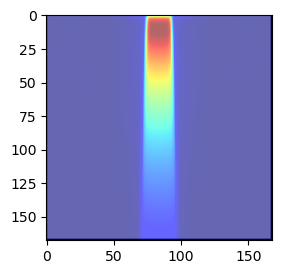

In [3]:
plt.subplot(121)
plt.imshow(np.transpose(sitk.GetArrayFromImage(ct_image), (1, 2, 0))[:, :, 100], cmap='gray')
plt.imshow(np.transpose(sitk.GetArrayFromImage(doses['1']), (1, 2, 0))[:, :, 100], cmap='jet', alpha=0.6)

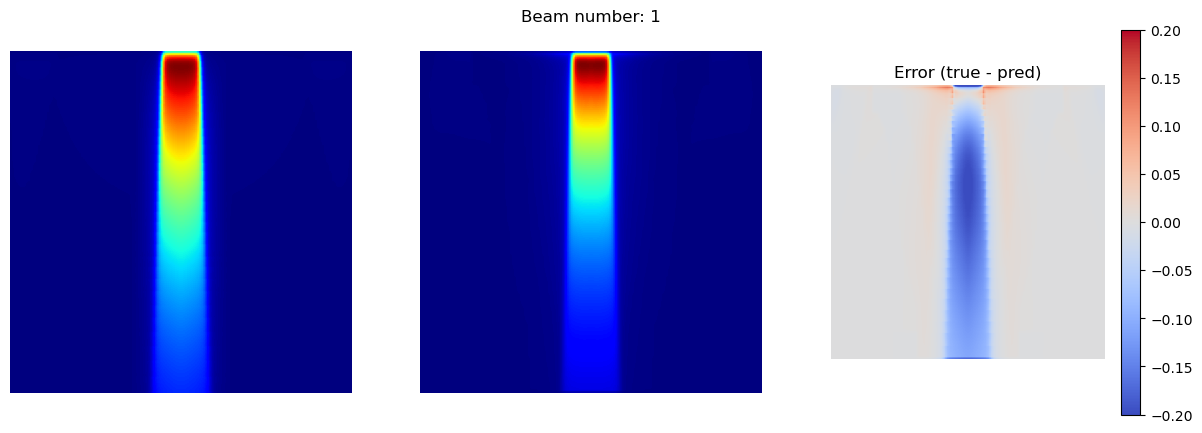

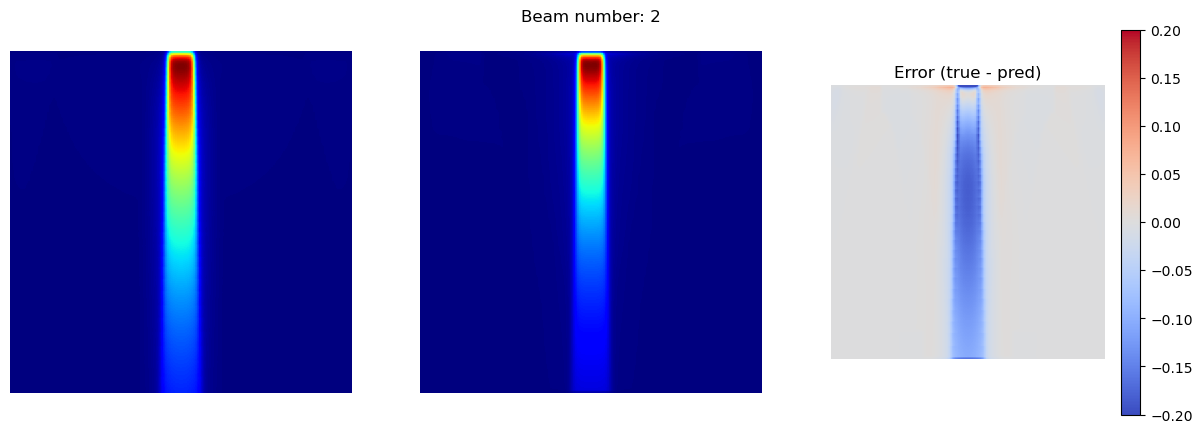

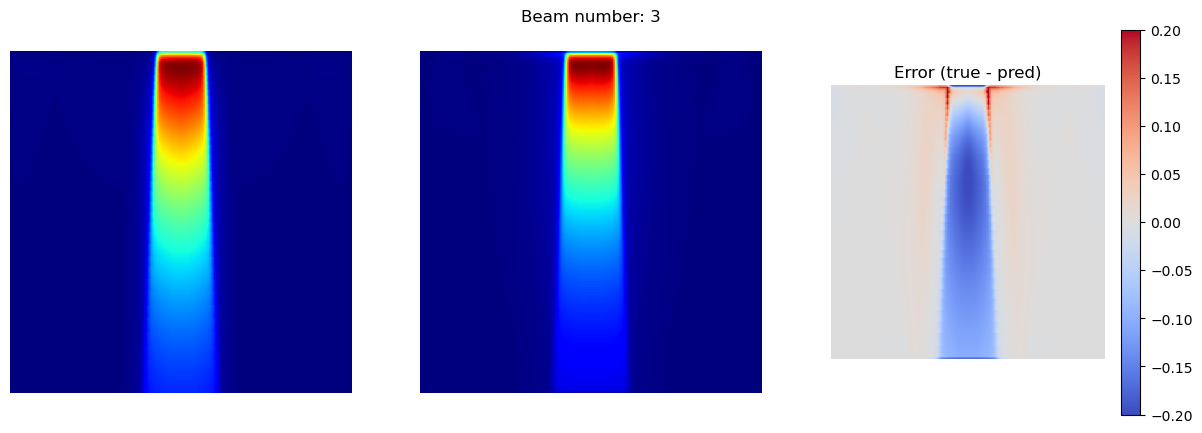

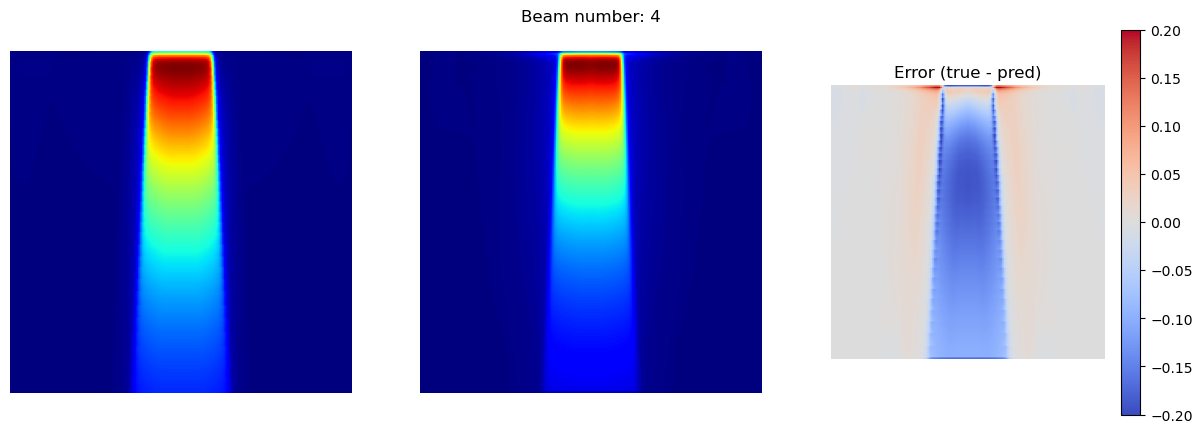

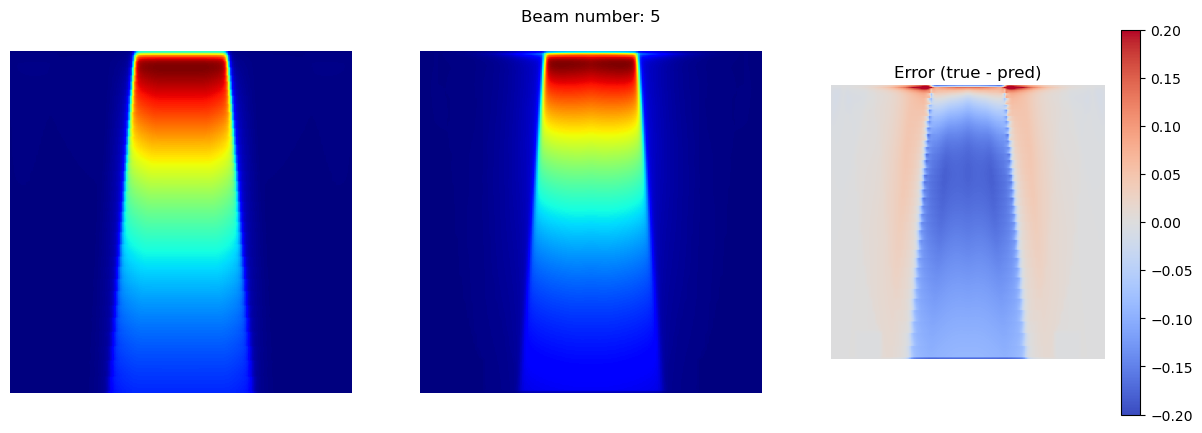

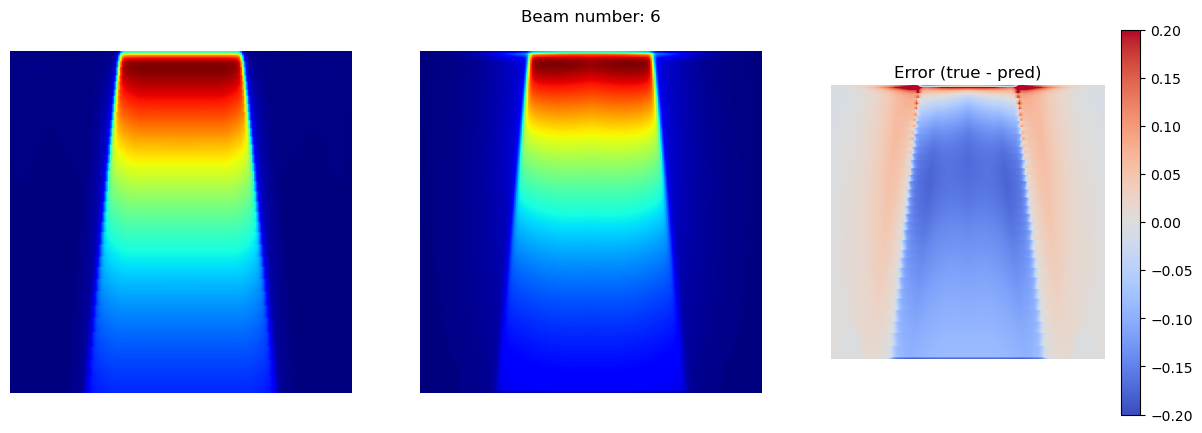

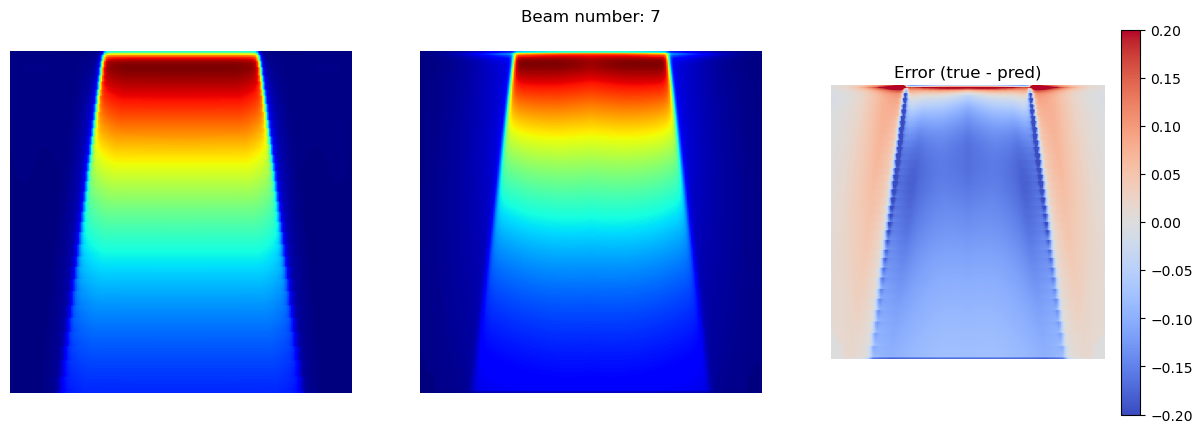

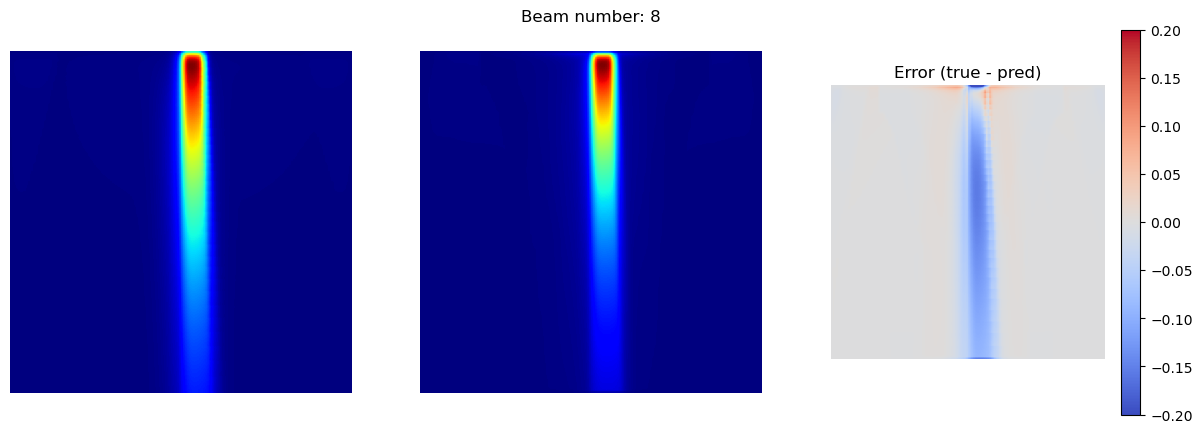

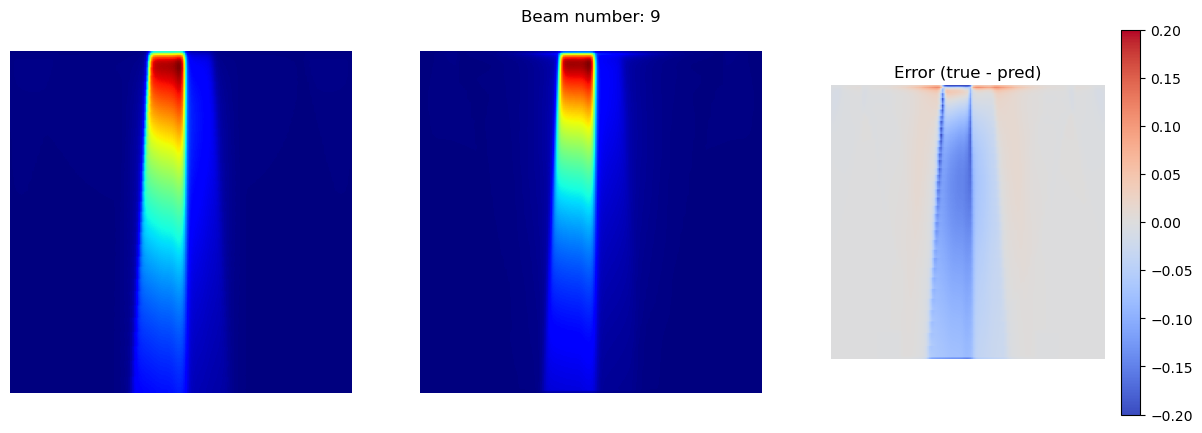

In [8]:
for beam_data in mlcs:
    beams = mlcs[beam_data]
    true_dose = doses[beam_data]

    if (beams[0]['angle'] != 0):
        continue

    config = MachineConfig(ct_array_shape=ct_image.GetSize(), resolution=np.divide(ct_image.GetSpacing(), 10), field_size=(40, 40), number_of_leaf_pairs=80, tpr_20_10=0.72, number_of_cps=1, starting_angle=0.5*math.radians(float(beams[0]['angle'])))
    
    dose_layer = AccumulateDose3DLayer(config, 25)
    
    # beams = sorted(beam_data, key=lambda x: x["angle"])
    mus = np.array([beam["mu"] + 1 for beam in beams])
    mus = np.diff(mus, prepend=0)
    mus = np.expand_dims(mus, axis=0)

    center = np.array([np.divide(np.array(beam["higher"]) + np.array(beam["lower"]), 2) for beam in beams], dtype=np.float32)
    width = np.array([beam["lower"] - center for beam, center in zip(beams, center)], dtype=np.float32)
    center += 200
    center /= 400
    width /= 200
    
    leafs = np.stack([center, width], axis=0)
    leafs = np.expand_dims(leafs, axis=0)

    dose_pred = dose_layer(np.expand_dims(np.transpose(np.array(sitk.GetArrayFromImage(ct_image), dtype=np.float32), (1, 2, 0)), 0), leafs, mus)

    true_slice = np.array(np.transpose(sitk.GetArrayFromImage(true_dose), (1, 2, 0))[:, :, 90], dtype=np.float32)
    pred_slice = dose_pred[0, :, :, 90]
    pred_slice *= (np.max(true_slice) / np.max(pred_slice))
    # true_slice /= np.max(true_slice)

    plt.figure(figsize=(15, 5))
    plt.title(f"Beam number: {beam_data}")
    plt.axis('off')
    plt.subplot(131)
    plt.imshow(pred_slice, cmap='jet')
    plt.axis('off')
    plt.subplot(132)
    plt.imshow(true_slice, cmap='jet')
    plt.axis('off')
    plt.subplot(133)
    plt.title('Error (true - pred)')
    plt.imshow(true_slice - pred_slice, cmap='coolwarm', vmin=-0.2, vmax=0.2)
    plt.colorbar()
    plt.axis('off')

    plt.show()
